In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Hotel_bookings_final.csv")
df.head()

C:\Users\Dell\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,customer_id,property_id,city,star_rating,booking_date,check_in_date,check_out_date,room_type,num_rooms_booked,stay_type,...,selling_price,payment_method,refund_status,refund_amount,channel_of_booking,booking_status,travel_date,cashback,coupon_redeem,Coupon USed?
0,492,3,San Francisco,4,2024-04-01,2024-05-24,2024-05-26,Standard,1,Leisure,...,25342,PayPal,Yes,369.648995,Web,Confirmed,2024-03-04,5.374694,0.000000,No
1,180,3,Dallas,3,2024-04-01,2024-05-10,2024-05-17,Deluxe,1,Leisure,...,8033,Bank Transfer,Yes,492.505903,Web,Confirmed,2024-07-19,7.161033,0.000000,No
2,50,5,Dallas,3,2024-04-01,2024-05-31,2024-06-05,Deluxe,1,Business,...,29715,Debit Card,Yes,0.000000,iOS,Confirmed,2024-03-22,0.000000,0.000000,No
3,294,3,Orlando,4,2024-04-01,2024-04-18,2024-04-24,Deluxe,3,Leisure,...,44592,Bank Transfer,Yes,545.541516,Android,Confirmed,2024-11-24,7.932170,24.500442,Yes
4,40,5,Seattle,5,2024-04-01,NaN,NaN,Deluxe,1,Leisure,...,15873,Debit Card,Yes,211.367602,Web,Cancelled,2024-03-02,0.000000,0.000000,No


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         30000 non-null  int64  
 1   property_id         30000 non-null  int64  
 2   city                30000 non-null  object 
 3   star_rating         30000 non-null  int64  
 4   booking_date        30000 non-null  object 
 5   check_in_date       24532 non-null  object 
 6   check_out_date      24532 non-null  object 
 7   room_type           30000 non-null  object 
 8   num_rooms_booked    30000 non-null  int64  
 9   stay_type           30000 non-null  object 
 10  booking_channel     30000 non-null  object 
 11  booking_value       30000 non-null  float64
 12  costprice           30000 non-null  int64  
 13  markup              30000 non-null  int64  
 14  selling_price       30000 non-null  int64  
 15  payment_method      30000 non-null  object 
 16  refu

,customer_id,property_id,star_rating,num_rooms_booked,booking_value,costprice,markup,selling_price,refund_amount,cashback,coupon_redeem
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,249.721767,3.777533,3.602033,1.352333,25080.525454,22541.494100,6963.32440,29504.818500,320.938376,3.831534,4.134988
std,145.484836,2.081471,0.860241,0.574403,11587.369335,9259.520787,2860.10657,12119.627338,339.635396,4.783590,10.846221
min,1.000000,1.000000,2.000000,1.000000,1279.770000,3822.000000,1181.00000,5003.000000,0.000000,0.000000,-3.532183
25%,123.000000,1.000000,3.000000,1.000000,15922.712500,15088.750000,4661.75000,19750.500000,0.000000,0.000000,0.000000
50%,248.000000,3.000000,4.000000,1.000000,24736.145000,22731.000000,7021.50000,29752.500000,221.141185,1.030180,0.000000
75%,376.000000,5.000000,4.000000,2.000000,33570.000000,30427.000000,9399.00000,39826.000000,594.624344,7.378533,0.000000
max,499.000000,7.000000,5.000000,3.000000,67764.460000,38200.000000,11800.00000,50000.000000,1462.725105,21.268013,89.644917


In [3]:
df.isnull().sum()

customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type                0
booking_channel          0
booking_value            0
costprice                0
markup                   0
selling_price            0
payment_method           0
refund_status            0
refund_amount            0
channel_of_booking       0
booking_status           0
travel_date              0
cashback                 0
coupon_redeem            0
Coupon USed?             0
dtype: int64

In [4]:
df[df['check_in_date'].isnull() & df['check_out_date'].isnull()].shape

(5468, 24)

In [5]:
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['check_in_date'] = pd.to_datetime(df['check_in_date'])
df['check_out_date'] = pd.to_datetime(df['check_out_date'])

df['stay_length'] = (df['check_out_date'] - df['check_in_date']).dt.days

df['stay_length'] = df['stay_length'].fillna(0).astype(int)

In [6]:
df = df.drop_duplicates()

In [7]:
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['check_in_date'] = pd.to_datetime(df['check_in_date'])
df['check_out_date'] = pd.to_datetime(df['check_out_date'])

In [8]:
df['stay_length'] = (df['check_out_date'] - df['check_in_date']).dt.days

In [9]:
df['month'] = df['booking_date'].dt.month

In [10]:
df['booking_channel'] = df['booking_channel'].str.strip().str.lower()
df['room_type'] = df['room_type'].str.title()

In [11]:
#Trend 1 — Booking distribution by channel

In [12]:
channel_trend = df['booking_channel'].value_counts()
print(channel_trend)

booking_channel
web             15001
mobile app      12009
travel agent     2990
Name: count, dtype: int64


In [13]:
#Trend 2 — Revenue contribution by room type

In [14]:
room_revenue = df.groupby('room_type')['booking_value'].sum().sort_values(ascending=False)
print(room_revenue.apply(lambda x: f"{x:,.0f}"))

room_type
Standard    416,232,654
Deluxe      261,997,832
Suite        74,185,277
Name: booking_value, dtype: object


In [15]:
#Trend 3 — Average stay length

In [16]:
avg_stay = df['stay_length'].mean()
print("Average stay length:", avg_stay)

Average stay length: 4.006848198271645


In [17]:
#Booking Patterns Analysis
#Channel Performance

In [18]:
channel_analysis = df.groupby('booking_channel').agg(
    total_bookings=('booking_channel','count'),
    avg_booking_value=('booking_value','mean'),
    cancellation_rate=('booking_status', lambda x: (x=='Cancelled').mean()*100)
).sort_values(by='total_bookings', ascending=False)

print(channel_analysis)

                 total_bookings  avg_booking_value  cancellation_rate
booking_channel                                                      
web                       15001       28190.840225          17.638824
mobile app                12009       21351.285716          21.558831
travel agent               2990       24453.972990          27.926421


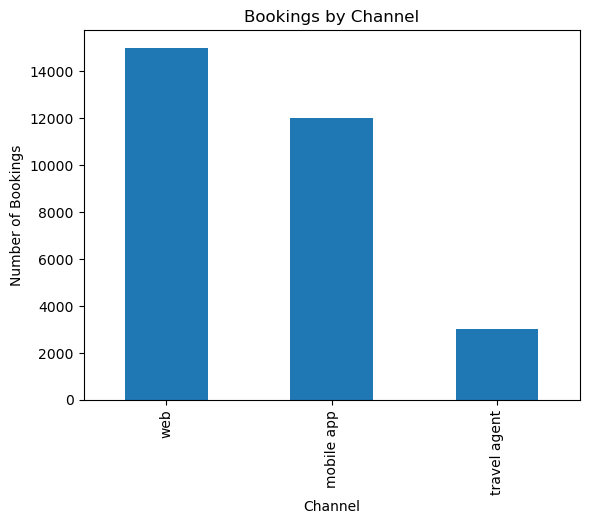

In [19]:
channel_bookings = df['booking_channel'].value_counts()

channel_bookings.plot(kind='bar')
plt.title("Bookings by Channel")
plt.ylabel("Number of Bookings")
plt.xlabel("Channel")
plt.show()

In [20]:
#Room Type

In [21]:
room_analysis = df.groupby('room_type').agg(
    bookings=('room_type','count'),
    avg_value=('booking_value','mean'),
    cancellation_rate=('booking_status', lambda x: (x=='Cancelled').mean()*100)
)

print(room_analysis)

           bookings     avg_value  cancellation_rate
room_type                                           
Deluxe        10478  25004.565025          16.024050
Standard      16552  25146.970413          23.302320
Suite          2970  24978.207751          17.979798


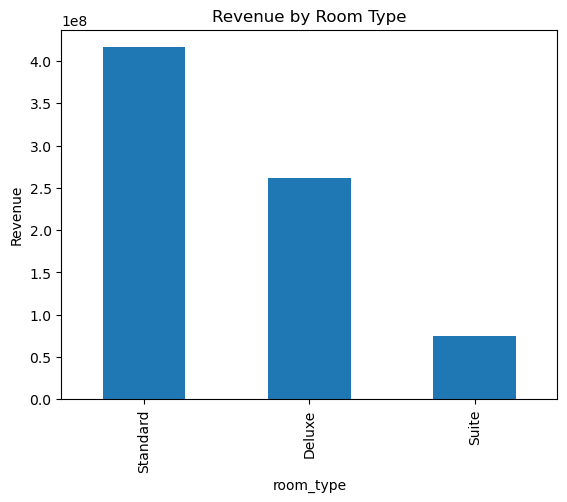

In [22]:
room_revenue.plot(kind='bar')
plt.title("Revenue by Room Type")
plt.ylabel("Revenue")
plt.show()

In [23]:
#Star Rating 

In [24]:
star_analysis = df.groupby('star_rating').agg(
    bookings=('star_rating','count'),
    avg_booking_value=('booking_value','mean'),
    cancellation_rate=('booking_status', lambda x: (x=='Cancelled').mean()*100)
)

print(star_analysis)

             bookings  avg_booking_value  cancellation_rate
star_rating                                                
2                2995       24855.819716          19.766277
3               10460       25209.567736          20.200765
4               12034       25010.623536          19.993352
5                4511       25116.972161          21.259144


In [25]:
# Cancellation Behavior
# Cancellation by channel

In [26]:
cancel_rate = (df['booking_status'] == 'Cancelled').mean() * 100
print("Overall cancellation rate:", cancel_rate)

Overall cancellation rate: 20.233333333333334


In [27]:
# Cancellation by channel

In [28]:
cancel_channel = df.groupby('booking_channel')['booking_status']\
    .apply(lambda x: (x=='Cancelled').mean()*100)

print(cancel_channel)

booking_channel
mobile app      21.558831
travel agent    27.926421
web             17.638824
Name: booking_status, dtype: float64


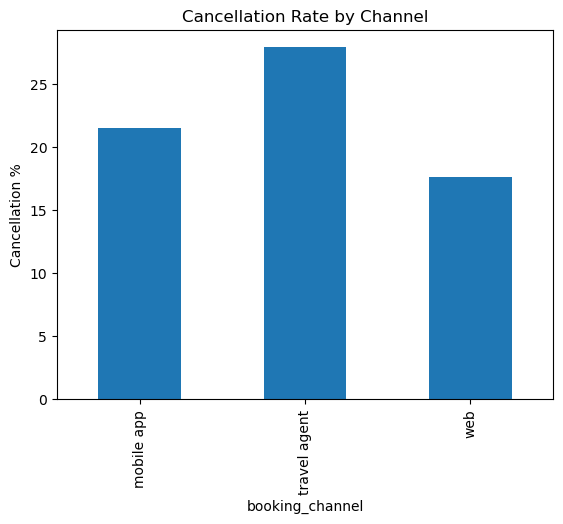

In [29]:
cancel_channel.plot(kind='bar')
plt.title("Cancellation Rate by Channel")
plt.ylabel("Cancellation %")
plt.show()

In [30]:
# Cancellation by room type

In [31]:
cancel_room = df.groupby('room_type')['booking_status']\
    .apply(lambda x: (x=='Cancelled').mean()*100)

print(cancel_room)

room_type
Deluxe      16.024050
Standard    23.302320
Suite       17.979798
Name: booking_status, dtype: float64


In [32]:
# Root Cause Analysis

In [33]:
# Why cancellations happen

In [36]:
df['lead_time'] = (df['check_in_date'] - df['booking_date']).dt.days
df['lead_time'] = df['lead_time'].fillna(0)

df['lead_time_bin'] = pd.cut(df['lead_time'], bins=5)

lead_cancel = df.groupby('lead_time_bin', observed=False)['booking_status'] \
    .apply(lambda x: (x == 'Cancelled').mean() * 100) \
    .reset_index()

print(lead_cancel)

   lead_time_bin  booking_status
0  (-0.06, 12.0]       50.286917
1   (12.0, 24.0]        4.213312
2   (24.0, 36.0]        4.088375
3   (36.0, 48.0]        4.237462
4   (48.0, 60.0]        4.079135


In [37]:
# Why some channels perform better

In [38]:
revenue_channel = df.groupby('booking_channel')['booking_value'].sum().sort_values(ascending=False)
print(revenue_channel)

booking_channel
web             4.228908e+08
mobile app      2.564076e+08
travel agent    7.311738e+07
Name: booking_value, dtype: float64


In [39]:
# Seasonal trends

In [40]:
monthly_bookings = df.groupby('month').size()
print(monthly_bookings)

month
1     2360
2     2132
3     2360
4     4494
5     2360
6     2284
7     2361
8     2360
9     2284
10    2360
11    2285
12    2360
dtype: int64


In [41]:
# Revenue trend

In [42]:
monthly_revenue = df.groupby('month')['booking_value'].sum()
print(monthly_revenue)

month
1     5.528121e+07
2     5.928334e+07
3     6.446651e+07
4     1.128735e+08
5     5.474528e+07
6     5.527916e+07
7     6.020926e+07
8     6.151278e+07
9     5.626658e+07
10    5.871826e+07
11    5.884617e+07
12    5.493369e+07
Name: booking_value, dtype: float64


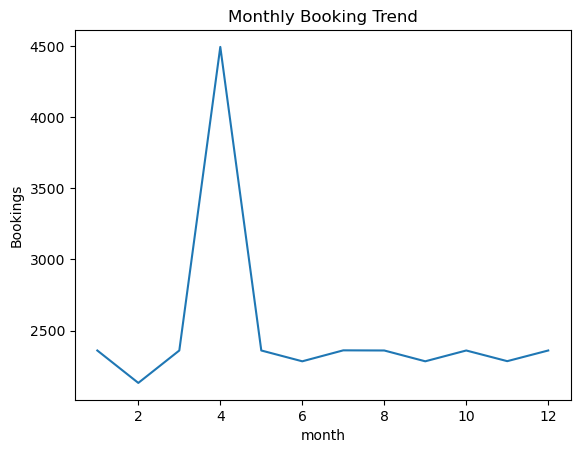

In [43]:
monthly_bookings.plot(kind='line')
plt.title("Monthly Booking Trend")
plt.ylabel("Bookings")
plt.show()

In [44]:
# Average stay by month

In [45]:
stay_trend = df.groupby('month')['stay_length'].mean()
print(stay_trend)

month
1     4.061193
2     4.057159
3     3.888542
4     4.044145
5     3.986486
6     4.023467
7     4.031151
8     4.003648
9     4.007576
10    3.986444
11    3.986849
12    3.975065
Name: stay_length, dtype: float64


In [46]:
# Strategy to Reduce Cancellations

In [47]:
high_risk = df.groupby(['booking_channel','room_type'])['booking_status']\
    .apply(lambda x: (x=='Cancelled').mean()*100).sort_values(ascending=False)

print(high_risk.head(10))

# If Travel Agent and Standard rooms cancel most:
#Focus policy there.

booking_channel  room_type
travel agent     Standard     31.062001
                 Deluxe       24.694836
mobile app       Standard     24.047763
travel agent     Suite        22.297297
mobile app       Suite        21.452145
web              Standard     21.186951
mobile app       Deluxe       17.651280
web              Suite        14.227086
                 Deluxe       12.958716
Name: booking_status, dtype: float64


In [48]:
# Improve profitability

In [49]:
top_revenue = df.groupby(['star_rating','room_type'])['booking_value'].sum() \
    .sort_values(ascending=False)

print(top_revenue.head(10).apply(lambda x: f"{x:,.0f}"))

# Target promotions here

star_rating  room_type
4            Standard     166,399,471
3            Standard     145,733,773
4            Deluxe       105,551,758
3            Deluxe        91,450,994
5            Standard      63,064,774
2            Standard      41,034,636
5            Deluxe        38,434,042
4            Suite         29,026,614
2            Deluxe        26,561,039
3            Suite         26,507,312
Name: booking_value, dtype: object


In [50]:
# Pricing Optimization

In [51]:
pricing_strategy = df.groupby('month')['booking_value'].mean()
print(pricing_strategy)

month
1     23424.240288
2     27806.446412
3     27316.317513
4     25116.494933
5     23197.152432
6     24202.785705
7     25501.593859
8     26064.735975
9     24635.105197
10    24880.617462
11    25753.245326
12    23276.987242
Name: booking_value, dtype: float64
